In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.simplefilter("ignore")

# 1. Data Loading and Preprocessing

In [2]:
# Creating data frame
df = pd.read_csv("/Users/shalini/Documents/GWU_SPRING 2024/Machine Learning/ML 2/bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
# Changing 'y' (target variable) into binary. (1 for yes and 0 for no)

df['y'] = np.where(df['y']=='yes',1,0).astype('int64')
counts_y = df['y'].value_counts()
print(counts_y)

y
0    39922
1     5289
Name: count, dtype: int64


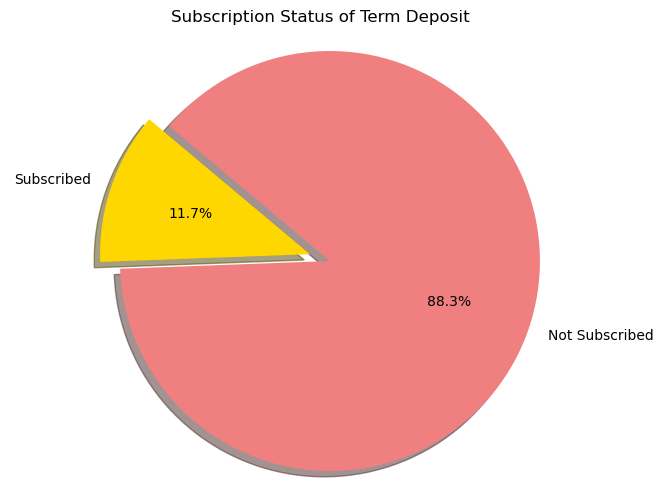

In [6]:
import matplotlib.pyplot as plt

# Counts of subscribers and non-subscribers
not_subscribed_count = 39922
subscribed_count = 5289

# Calculate percentages
total_count = subscribed_count + not_subscribed_count
subscribed_percentage = (subscribed_count / total_count) * 100
not_subscribed_percentage = (not_subscribed_count / total_count) * 100

# Data to plot
labels = 'Subscribed', 'Not Subscribed'
sizes = [subscribed_percentage, not_subscribed_percentage]
colors = ['gold', 'lightcoral']
explode = (0.1, 0)  # explode 1st slice (Subscribed)

# Plot
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Subscription Status of Term Deposit')
plt.show()

In our data there are total term deposit subscription as 5289 and those who have not subscribed are 39922. 

In order to increase the subscription of Term deposit so that Bank can earn the profit we are diving into the data and suggest meaningful steps to increase the subcription. Data is Imbalanced

In [7]:
# Balance the Data
from sklearn.utils import resample

# Separate majority and minority classes
df_majority = df[df['y'] == 0]
df_minority = df[df['y'] == 1]

# Undersample majority class
df_majority_downsampled = resample(df_majority, 
                                   replace=False,    
                                   n_samples=len(df_minority), 
                                   random_state=42) 

# Combine minority and downsampled majority class
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the dataset
df = df_balanced.sample(frac=1, random_state=42)

# Check the new class distribution
print(df['y'].value_counts())


y
1    5289
0    5289
Name: count, dtype: int64


In [8]:
#Data is balanced
#Finding the duplicates: duplicates are not found in the data
#negative pdays values are removed :   value of -1 indicates that the customer hasn’t been contacted since the previous campaign. Pdays is the number of days that passed by after the customer was last contacted from a previous campaign.indicated that the customer has never been contacted since the previous campaign while positive value indicates how much time the customer is contacted. Dat is changed  as data  '1' if customer is contacted and to '0' if customer is not contacted  
#unknown Job: Job is not known, Job: for 30 are found unknown for category 1, we removed the people with unknown job.
#Unknown in Contact and p: The contact data 456 for catgory 1 and 10213 for category 0,mode of contact is not known,its not advisable to remove so we have put it into other category.
#poutcome are changed to other as the poutcome is the outcome of previous campaign it can be sucess, failure or outcome not known so we have moved all other to unknown values,these are 1321 and 281 for Category 0 and 1  respectively.
#we dont find any missing values.


In [9]:
# Check target label split over categorical features 
categorical_features=[feature for feature in df.columns if ((df[feature].dtypes=='O') & (feature not in ['y']))]

for categorical_feature in categorical_features:
    print(df.groupby(['y',categorical_feature]).size())

y  job          
0  admin.            598
   blue-collar      1232
   entrepreneur      164
   housemaid         166
   management       1066
   retired           233
   self-employed     167
   services          490
   student            81
   technician        896
   unemployed        163
   unknown            33
1  admin.            631
   blue-collar       708
   entrepreneur      123
   housemaid         109
   management       1301
   retired           516
   self-employed     187
   services          369
   student           269
   technician        840
   unemployed        202
   unknown            34
dtype: int64
y  marital 
0  divorced     601
   married     3212
   single      1476
1  divorced     622
   married     2755
   single      1912
dtype: int64
y  education
0  primary       847
   secondary    2765
   tertiary     1470
   unknown       207
1  primary       591
   secondary    2450
   tertiary     1996
   unknown       252
dtype: int64
y  default
0  no         5193
 

In [10]:
# Checking for duplicates in our data

df.duplicated().sum()

0

In [11]:
# Fixing pdays column in the data frame

if 'pdays' in df.columns:
    
    # Replace values in 'pdays' column

    df['pdays'] = np.where(df['pdays'] < 0, 0, 1)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
2831,39,management,divorced,tertiary,no,517,yes,yes,unknown,14,may,1328,1,0,0,unknown,1
26462,30,services,married,secondary,no,3929,yes,no,cellular,20,nov,593,1,0,0,unknown,1
43328,46,management,divorced,tertiary,no,624,no,no,cellular,18,mar,420,1,1,1,other,1
39899,32,admin.,married,tertiary,no,653,no,no,cellular,2,jun,84,1,0,0,unknown,1
37020,36,blue-collar,married,primary,no,319,yes,no,cellular,13,may,774,2,1,1,failure,1


In [12]:
# Removing any customer with 'unknown' job

df = df[~df['job'].isin(['unknown'])].reset_index(drop=True)

In [13]:
# Replace 'unknown' with 'other' in contact

df['contact'].replace(['unknown'], ['other'], inplace=True)

In [14]:
# Replace 'other' with 'unknown' in poutcome

df['poutcome'].replace(['other'], ['unknown'], inplace=True)

In [15]:
# Identifying data with missing values

missing_values = df.isna().sum()
print("Missing values count per column:")
print(missing_values)

Missing values count per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [16]:
import pandas as pd

# Remove rows where 'balance' ,column is negative
df = df[df['balance']>0]

# 2. Categorical data Analysis

In [17]:
categorical_features=[feature for feature in df.columns if ((df[feature].dtypes=='O') & (feature not in ['y']))]
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [18]:
for feature in categorical_features:
    print('The feature is {} and number of categories are {}'.format(feature,len(df[feature].unique())))

The feature is job and number of categories are 11
The feature is marital and number of categories are 3
The feature is education and number of categories are 4
The feature is default and number of categories are 2
The feature is housing and number of categories are 2
The feature is loan and number of categories are 2
The feature is contact and number of categories are 3
The feature is month and number of categories are 12
The feature is poutcome and number of categories are 3


There are 9 categorical features

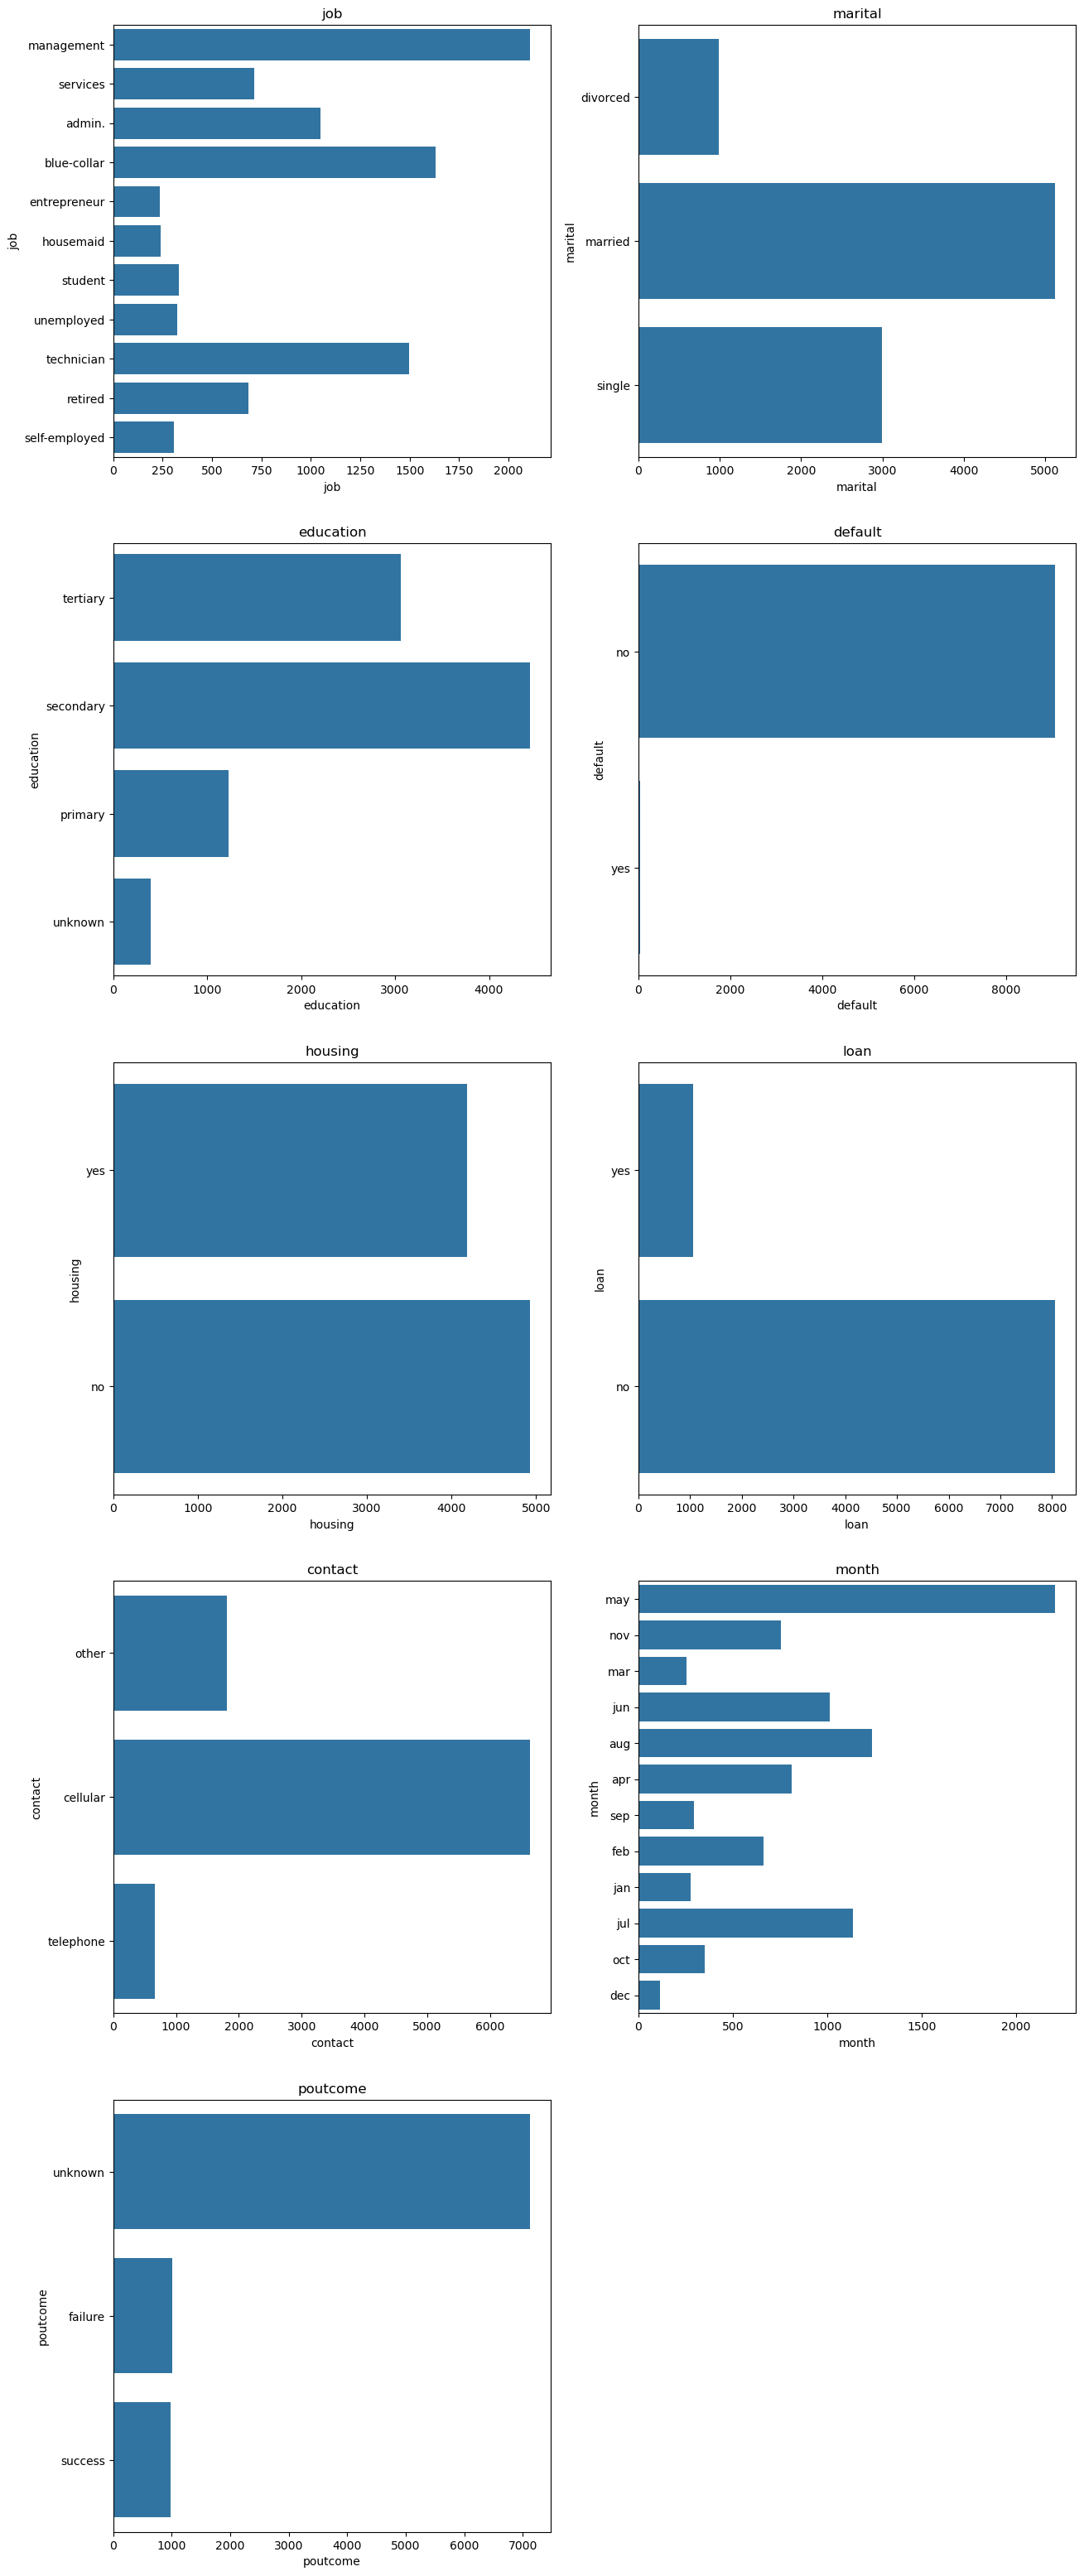

In [19]:
plt.figure(figsize=(15,80), facecolor='white')
plotnumber =1
for categorical_feature in categorical_features:
    ax = plt.subplot(10,2,plotnumber)
    sns.countplot(y=categorical_feature,data=df)
    plt.xlabel(categorical_feature)
    plt.title(categorical_feature)
    plotnumber+=1
plt.show()



1. Client with job type as 'management' are highest in our dataset and 'student' are the least.
2. Majority of the clients in our dataset are 'married' where as 'divorced' are the least.
3. Client with education background as 'secondary' are in high numbers in our dataset.
4. Data in month of may is highest and is least in december.




In [20]:
# Check target label split over categorical features 
for categorical_feature in categorical_features:
    print(df.groupby(['y',categorical_feature]).size())

y  job          
0  admin.            483
   blue-collar      1014
   entrepreneur      136
   housemaid         139
   management        899
   retired           200
   self-employed     135
   services          401
   student            73
   technician        741
   unemployed        137
1  admin.            565
   blue-collar       618
   entrepreneur       98
   housemaid          99
   management       1210
   retired           482
   self-employed     170
   services          313
   student           258
   technician        757
   unemployed        187
dtype: int64
y  marital 
0  divorced     463
   married     2650
   single      1245
1  divorced     530
   married     2474
   single      1753
dtype: int64
y  education
0  primary       696
   secondary    2256
   tertiary     1237
   unknown       169
1  primary       528
   secondary    2180
   tertiary     1822
   unknown       227
dtype: int64
y  default
0  no         4332
   yes          26
1  no         4740
   yes       

# 3. Numericla value features Data Analysis

In [21]:
# Changing 'education' into numerical value.

df['education'] = np.where(df['education'] == 'primary', 1,
                  np.where(df['education'] == 'secondary', 2,
                  np.where(df['education'] == 'tertiary', 3, 0)))

In [22]:
# List of numerical variables
numerical_features = [feature for feature in df.columns if ((df[feature].dtypes != 'O') & (feature not in ['y']))]
print('Number of numerical variables: ', len(numerical_features))

# Visualise the numerical variables

df[numerical_features].head()

Number of numerical variables:  8


,age,education,balance,day,duration,campaign,pdays,previous
0,39,3,517,14,1328,1,0,0
1,30,2,3929,20,593,1,0,0
2,46,3,624,18,420,1,1,1
3,32,3,653,2,84,1,0,0
4,36,1,319,13,774,2,1,1


In [23]:
# List of discrete features

discrete_features = [feature for feature in numerical_features if len(df[feature].unique()) < 25]
print("Discrete Variables Count: {}".format(len(discrete_features)))
discrete_features

Discrete Variables Count: 2


['education', 'pdays']

In [24]:
# List of continuous features

continuous_features=[feature for feature in numerical_features if feature not in discrete_features+['y']]
print("Continuous feature Count {}".format(len(continuous_features)))
continuous_features

Continuous feature Count 6


['age', 'balance', 'day', 'duration', 'campaign', 'previous']

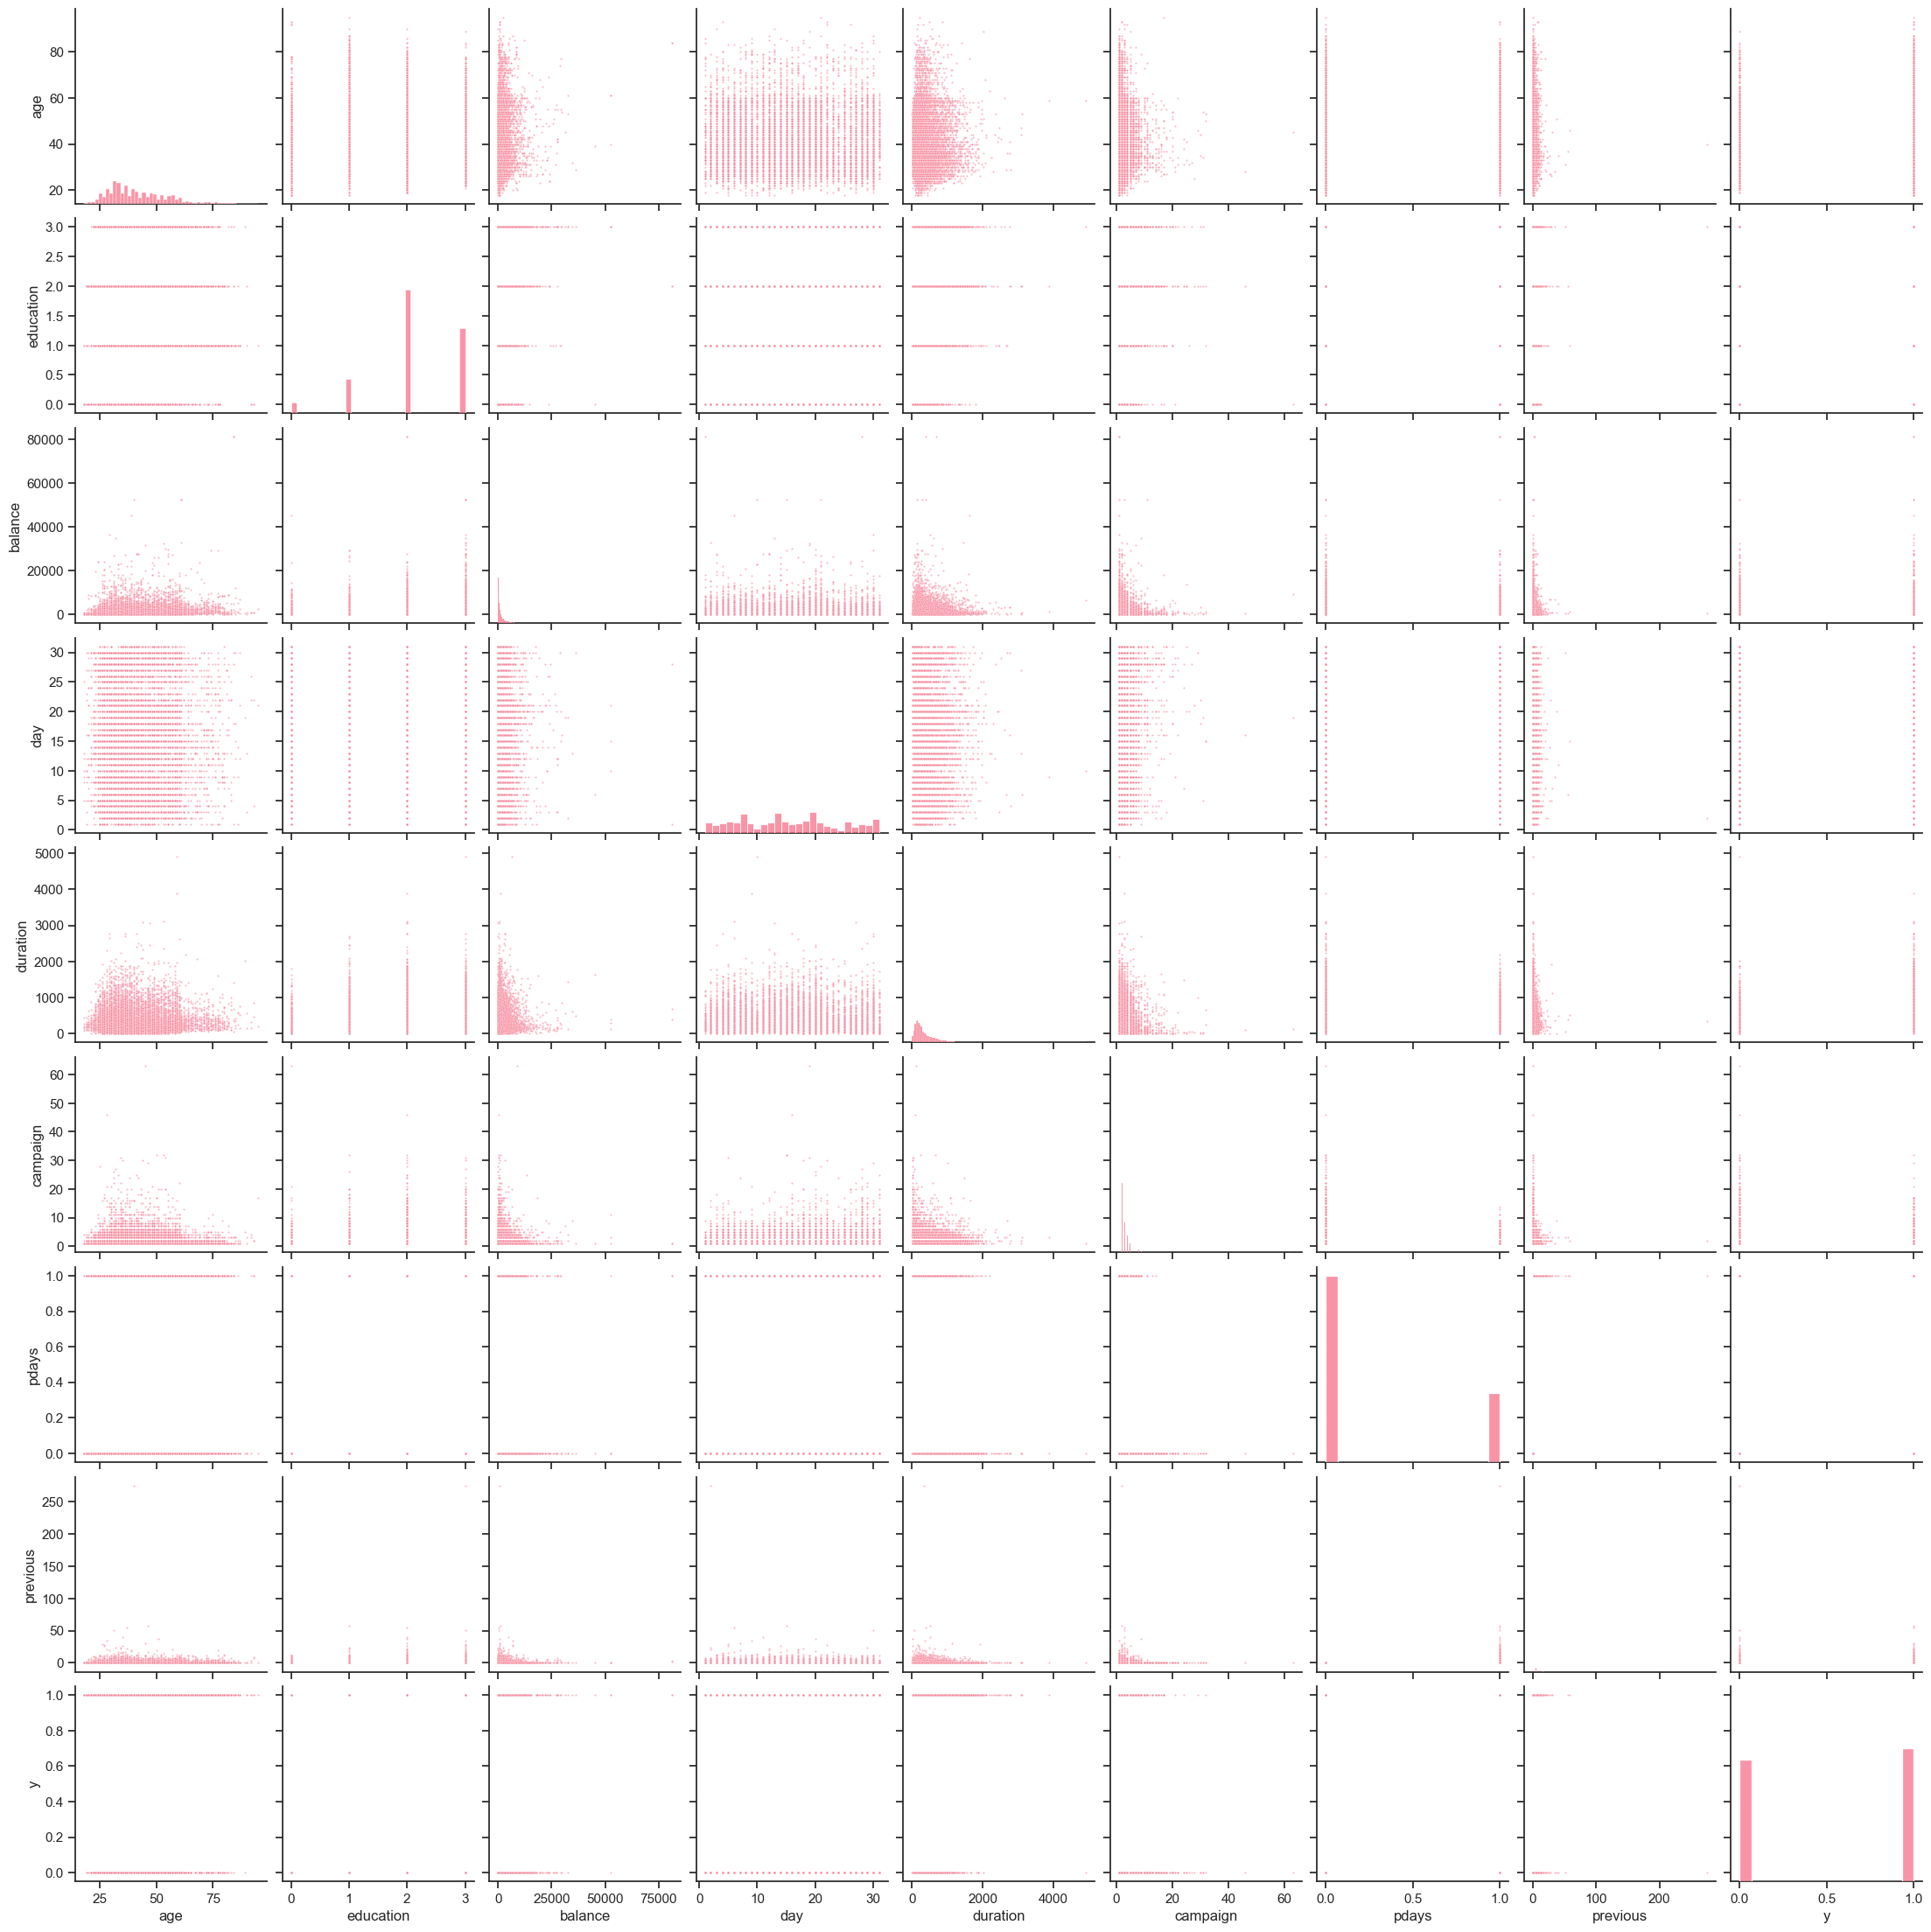

In [25]:
# Define your custom color palette
custom_palette = sns.color_palette("husl")  # You can choose any palette you like

# Set the style and palette
sns.set(style="ticks", palette=custom_palette)

# Increase marker size and decrease transparency
g = sns.pairplot(df, markers='.', plot_kws={'alpha': 0.5, 's': 10})

# Show the pair plot
plt.show()


In [26]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,39,management,divorced,3,no,517,yes,yes,other,14,may,1328,1,0,0,unknown,1
1,30,services,married,2,no,3929,yes,no,cellular,20,nov,593,1,0,0,unknown,1
2,46,management,divorced,3,no,624,no,no,cellular,18,mar,420,1,1,1,unknown,1
3,32,admin.,married,3,no,653,no,no,cellular,2,jun,84,1,0,0,unknown,1
4,36,blue-collar,married,1,no,319,yes,no,cellular,13,may,774,2,1,1,failure,1


In [27]:
# Dividing the data into test and Train : 70% of data as Test data

In [28]:
# Label Encode Categorical Features

from sklearn.preprocessing import LabelEncoder

# Create a label encoder object
le = LabelEncoder()

# Encode categorical features
le_count = 0
for col in df.columns[:-1]: # Exclude the last column (assuming it's the target variable)
    if df[col].dtype == 'object':
        le.fit(df[col])
        df[col] = le.transform(df[col])
        le_count += 1
print('{} columns were label encoded.'.format(le_count))

8 columns were label encoded.


In [29]:
from sklearn.model_selection import train_test_split
# Prepare for X and y
y = df.y
X = df.drop('y',axis=1)

# Randomly split into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.70) 


# 4. Different Classifier to predict Accuracy of the model

In [30]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
from xgboost import XGBClassifier


# Initialize classifiers in consideration
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('KNN', KNeighborsClassifier(n_neighbors=3)),
    ('Gaussian NB', GaussianNB()),
    ('Decision Tree Classifier', DecisionTreeClassifier(criterion='entropy')),
    ('Random Forest', RandomForestClassifier(n_estimators=100, criterion='entropy')),
    ('Bagging Classifier', BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100)),
    ('Gradient Boosting Classifier', GradientBoostingClassifier(n_estimators=100)),
    ('XGBoost Classifier', XGBClassifier(objective='binary:logistic', learning_rate=0.5, max_depth=3, n_estimators=100))
]


# Evaluate Model Results:
acc_results = []
auc_results = []
names = []

# set table to table to populate with performance results
col = ['Algorithm', 'AUC Mean', 'AUC STD', 'Accuracy Mean', 'Accuracy STD']
model_results = pd.DataFrame(columns=col)

# Evaluate each model using k-fold cross-validation:
i = 0
for name, model in models:
    kfold = KFold(n_splits=10)
    # accuracy scoring:
    cv_acc_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    # roc_auc scoring:
    cv_auc_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='roc_auc')
    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)
    model_results.loc[i] = [name,
                         round(cv_auc_results.mean()*100, 2),
                         round(cv_auc_results.std()*100, 2),
                         round(cv_acc_results.mean()*100, 2),
                         round(cv_acc_results.std()*100, 2)
                         ]
    i += 1
    
model_results.sort_values(by=['AUC Mean'], ascending=False)

,Algorithm,AUC Mean,AUC STD,Accuracy Mean,Accuracy STD
4,Random Forest,90.43,1.47,84.45,1.90
6,Gradient Boosting Classifier,90.19,1.54,83.32,0.98
7,XGBoost Classifier,89.94,2.31,83.14,2.70
5,Bagging Classifier,89.71,1.53,82.77,1.63
0,Logistic Regression,85.59,2.83,78.86,2.49
2,Gaussian NB,79.38,3.77,70.48,3.41
3,Decision Tree Classifier,75.98,2.95,76.30,2.42
1,KNN,72.34,2.37,67.41,1.94


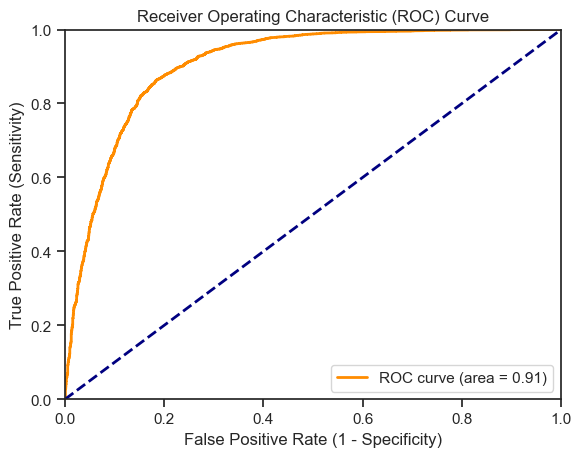

In [31]:
from sklearn.metrics import roc_curve, auc
# Fit a Random Forest classifier
clf = XGBClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict probabilities for the positive class
y_proba = clf.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

An AUC-ROC value of 0.91 indicates that the model has good discriminatory power and is able to distinguish between the positive and negative classes quite effectively.

# 5. Confusion Matrix

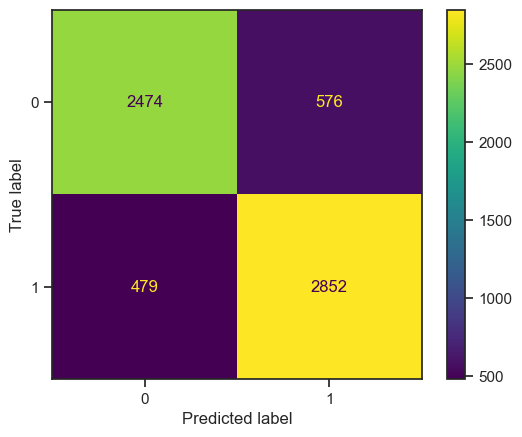

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Initialize and train the Random Forest classifier
rf_model = XGBClassifier(learning_rate=0.5,max_depth=3,n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = rf_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)

disp.plot()
plt.show()

# 6. Expected Value Framework
Assumptions: LoanInterestRate = 6%
Term Deposit Rate = 3.2%

In [33]:
# We are assuming that the customer is investing 35% of the balance.
LoanInterestRate = 6
FixedDepositRate = 3.2
call = 1
meanAmount = 2003.45
c = 0
for x in y_pred:
    if x == 1:
        c += 1
arr = []
bal =[]
for t in X_test['balance']:
    bal.append(t)
for x in y_test:
    arr.append(x)
    
tp = 0
tn = 0
fp = 0
fn = 0
prof = 0
i = 0
while i < len(y_pred):
    if y_pred[i] == 1 and arr[i] == 1:
        tp += 1
        prof = prof + bal[i]*0.35*(LoanInterestRate - FixedDepositRate) - call # assumption of 35%
    elif y_pred[i] == 1 and arr[i] == 0:
        fp += 1
        prof = prof - 1
    elif y_pred[i] == 0 and arr[i] == 1:
        fn += 1
    elif y_pred[i] == 0 and arr[i] == 0:
        tn += 1
    i += 1

meanprof = prof/c
prof_rounded = round(prof, 2)
meanprof_rounded = round(meanprof, 2)
total = tp + fp + tn + fn
TruePositiveRate = tp/(tp + fn)
FalsePositiveRate = fp/(fp + tn)
TrueNegativeRate = tn/(tn + fp)
FalseNegativeRate = fn/(fn + tp)

accuracy = (tp + tn)/total
precision = tp/(tp + fp)
recall = tp/(tp + fn)
F1Score = 2 * precision * recall/(precision + recall)

Ppos = (tp + fn)/total # likelyhood of seeing a positive instance
Pneg = (tn + fp)/total # likelyhood of seeing a negative instance

print("Total Net Profit incurred by the bank using the model : ",prof_rounded)
print("Mean profit(individual profit average) incurred by the bank : ", meanprof_rounded)
print("False Negative: ", fn)
print("False Positive: ", fp)
print("True Negative: ", tn)
print("True Positive: ", tp)
print("TruePositiveRate/Sensitivity: ", TruePositiveRate)
print("FalsePositiveRate/Fallout: ", FalsePositiveRate)
print("TrueNegativeRate/Specificity: ", TrueNegativeRate)
print("FalseNegativeRate/Miss: ", FalseNegativeRate)

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1Score: ", F1Score)

print("P(positive): ", Ppos)
print("P(negative): ", Pneg)

Total Net Profit incurred by the bank using the model :  5793813.94
Mean profit(individual profit average) incurred by the bank :  1690.14
False Negative:  479
False Positive:  576
True Negative:  2474
True Positive:  2852
TruePositiveRate/Sensitivity:  0.8561993395376764
FalsePositiveRate/Fallout:  0.18885245901639344
TrueNegativeRate/Specificity:  0.8111475409836065
FalseNegativeRate/Miss:  0.14380066046232362
Accuracy:  0.8346654129446796
Precision:  0.8319719953325554
Recall:  0.8561993395376764
F1Score:  0.8439118212753366
P(positive):  0.5220184923993104
P(negative):  0.4779815076006895


# 7. Analysis of 'balance' and Target variable 'y'(Term deposit)

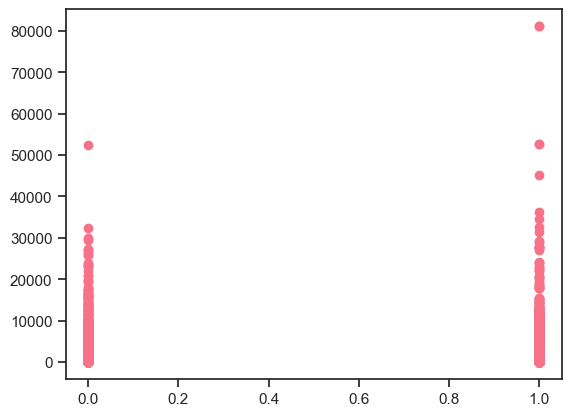

In [34]:
# Scatterplot balance vs y
plt.scatter(df['y'], df['balance'])

In [35]:
# Sort the dataframe by the 'balance' column in ascending order
df = df.sort_values(by='balance', ascending=True)


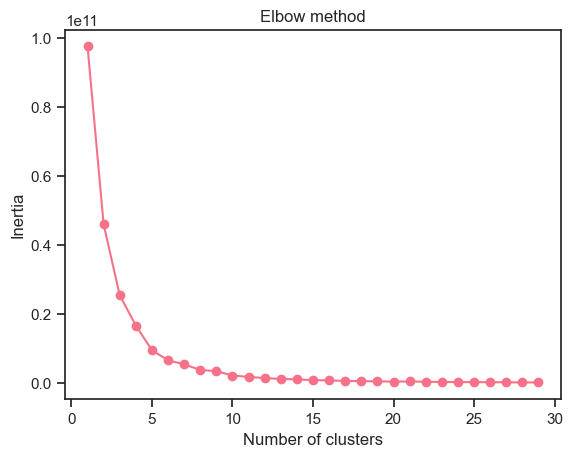

In [36]:
# K means between 'balance' and 'y'
from sklearn.cluster import KMeans
xcord = df['balance']
ycord = df['y']
data = list(zip(xcord,ycord))
inertias = []

for i in range(1,30):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,30), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

From above figure elbow method we found that the curve is flattening at 7. Hence, We have choosen a cluster size of 7 for our Analysis

In [37]:
# Clusters represented by differnt Clusters 0-4 by different colors.

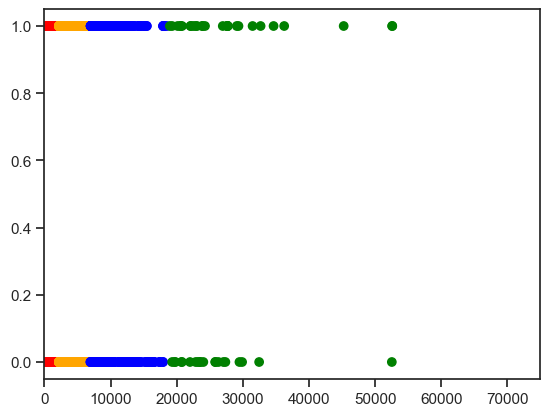

In [38]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 5)
kmeans.fit(data)

# Define custom colors for clusters
colors = ['red', 'blue', 'green', 'orange', 'purple']

# Plot the scatter plot with custom colors for clusters
plt.scatter(xcord, ycord, c=[colors[label] for label in kmeans.labels_])
plt.xlim(0, 75000)
plt.show()


#Clustering of 'balance'

In [39]:
from collections import Counter

# Assuming kmeans.labels_ contains the cluster labels assigned by k-means
cluster_counts = Counter(kmeans.labels_)

for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} data points")

Cluster 0: 6984 data points
Cluster 3: 1695 data points
Cluster 1: 385 data points
Cluster 2: 49 data points
Cluster 4: 2 data points


In [40]:
# 8. Maximum and Minimum Balance in each cluster

In [41]:
# Combine cluster labels
df['Cluster'] = kmeans.labels_
table = []
for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]
    max_balance = cluster_data['balance'].max()
    min_balance = cluster_data['balance'].min()
    table.append([min_balance, max_balance])
    print(f"Cluster {cluster}: Max balance = {max_balance}, Min balance = {min_balance}")

Cluster 0: Max balance = 2188, Min balance = 1
Cluster 3: Max balance = 6900, Min balance = 2189
Cluster 1: Max balance = 18508, Min balance = 6945
Cluster 2: Max balance = 52587, Min balance = 18967
Cluster 4: Max balance = 81204, Min balance = 81204


# 9. Term Deposit yes or no subscription according to Cluster

In [42]:
x = 0
cr = []
while x < 5:
    target_cluster = x
    count_y0 = 0
    count_y1 = 0
    for index, row in df.iterrows():
        if row['Cluster'] == x:
            if row['y'] == 0:
                count_y0 += 1
            elif row['y'] == 1:
                count_y1 += 1  

    total = count_y0 + count_y1
    rate = round((count_y1/total)*100,2)
    cr.append([x,rate])
    print(f"Number of data points in cluster {target_cluster} with y-coordinate 0: {count_y0}")
    print(f"Number of data points in cluster {target_cluster} with y-coordinate 1: {count_y1}")

    x += 1
    print('\n')  
print(f"Cluster and Conversion rate: {cr}")

Number of data points in cluster 0 with y-coordinate 0: 3525
Number of data points in cluster 0 with y-coordinate 1: 3459


Number of data points in cluster 1 with y-coordinate 0: 158
Number of data points in cluster 1 with y-coordinate 1: 227


Number of data points in cluster 2 with y-coordinate 0: 20
Number of data points in cluster 2 with y-coordinate 1: 29


Number of data points in cluster 3 with y-coordinate 0: 655
Number of data points in cluster 3 with y-coordinate 1: 1040


Number of data points in cluster 4 with y-coordinate 0: 0
Number of data points in cluster 4 with y-coordinate 1: 2


Cluster and Conversion rate: [[0, 49.53], [1, 58.96], [2, 59.18], [3, 61.36], [4, 100.0]]


In [43]:
# Label Encode Categorical Features
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encode categorical features
le_count = 0
for col in df.columns[:-1]: # Exclude the last column (assuming it's the target variable)
    if df[col].dtype == 'object':
        le.fit(df[col])
        df[col] = le.transform(df[col])
        le_count += 1
print('{} columns were label encoded.'.format(le_count))

0 columns were label encoded.


The above code list term deposits subscription from the cluster.Here, we can see that from a particular cluster how many have opted for Term deposit and how many are nottaking the term deposit.

In [44]:
# Calculating mean balance of people who term deposited their money 
summ = 0
count = 0
for index, row in df.iterrows():
    if row['balance'] > 0 and row['y'] == 1:
        summ = summ + row['balance']
        count = count + 1
        
mean = (summ/count)
print(f"Average account balance of people who deposit their money: {mean:.2f}")

Average account balance of people who deposit their money: 2003.46
